
# Train–Test Split

All data splits used for model training were generated in advance.

Initially, three different random seeds were used to perform a **3 × 5-fold cross-validation** (three seeds, each with five folds).  
However, for the final model training and evaluation, **only the splits generated with seed 42 were used**, resulting in a **single 5-fold cross-validation**.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
cases_df = pd.read_csv('cleaned_collected_cases_final_with_FEV1.csv')
cases_df.head()

,PatientID,BaselineDate,SeriesUID,Image,Mask,Followup FVC Predicted %,Baseline FVC Predicted %,Baseline SeriesInstanceUID,Depth,NonzeroDepth,...,Baseline Acquisition Date,Baseline FVC Week,Delta FVC,Followup FVC DATE,Primary Diagnosis,Followup FVC Week,Followup Acquisition Date,Age,Smoking History,FEV1 Volume L
0,1001326,1971-01-01,1.2.826.0.1.3680043.10.1218.729327262603124254...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,94.70,95.7,1.2.826.0.1.3680043.10.1218.729327262603124254...,983.0,591.0,...,1971-01-01,0,-0.03,1972-01-21,CTD-ILD,55.0,NaN,71.000000,Ex Smoker,2.03
1,298078,1967-10-09,1.2.392.200036.9116.2.6.1.3268.2047398422.1539...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,118.10,96.7,1.2.392.200036.9116.2.6.1.3268.2047398422.1539...,396.0,254.0,...,1967-10-09,0,0.47,1968-10-28,UILD,55.0,NaN,65.955446,Never Smoker,2.01
2,727988,1970-10-05,1.2.392.200036.9116.2.6.1.3268.2047398422.1581...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,68.40,75.8,1.2.392.200036.9116.2.6.1.3268.2047398422.1581...,376.0,235.0,...,1970-10-05,0,-0.25,1971-09-27,UILD,49.0,NaN,65.955446,Ex Smoker,2.23
3,1001092,1980-01-01,1.2.826.0.1.3680043.10.1218.114401689482668046...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,88.03,88.3,1.2.826.0.1.3680043.10.1218.114401689482668046...,290.0,204.0,...,1980-01-01,0,-0.03,1981-01-21,UILD,55.0,NaN,80.000000,Never Smoker,2.65
4,772512,1973-10-01,1.2.392.200036.9116.2.6.1.3268.2047398422.1563...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,77.20,73.9,1.2.392.200036.9116.2.6.1.3268.2047398422.1563...,396.0,256.0,...,1973-10-01,0,0.09,1974-09-23,UILD,51.0,1974-09-23,74.000000,Ex Smoker,2.10


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

patients = cases_df['PatientID'].unique()

seeds = [42]#, 24, 7]
fixed_test_seed = 42

# Create one shared train/test split for fair comparison across seeds
shared_train_patients, shared_test_patients = train_test_split(
    patients, test_size=0.15, random_state=fixed_test_seed
)

# Save the same shared split into each seed directory
for seed in seeds:
    output_directory = f'Patient_Splits_Seed{seed}'
    os.makedirs(output_directory, exist_ok=True)
    pd.DataFrame({'PatientID': shared_train_patients}).to_csv(
        os.path.join(output_directory, 'train_patients.csv'), index=False
    )
    pd.DataFrame({'PatientID': shared_test_patients}).to_csv(
        os.path.join(output_directory, 'test_patients.csv'), index=False
    )


In [4]:
print(f'Total patients: {len(patients)}')
print(f'Shared training patients: {len(shared_train_patients)}')
print(f'Shared testing patients: {len(shared_test_patients)}')

Total patients: 556
Shared training patients: 472
Shared testing patients: 84


In [5]:
# for each split, create 5 folds for training and validation
from sklearn.model_selection import KFold
import numpy as np

for seed in seeds:
    train_ids = pd.read_csv(f'Patient_Splits_Seed{seed}/train_patients.csv')['PatientID'].values
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    
    folds = []
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(train_ids)):
        folds.append((train_ids[train_idx], train_ids[val_idx]))

    # Save the folds to CSV files
    output_directory = f'Patient_Splits_Seed{seed}'
    for fold_idx, (train_fold, val_fold) in enumerate(folds):
        pd.DataFrame({'PatientID': train_fold}).to_csv(os.path.join(output_directory, f'train_fold_{fold_idx}.csv'), index=False)
        pd.DataFrame({'PatientID': val_fold}).to_csv(os.path.join(output_directory, f'val_fold_{fold_idx}.csv'), index=False)

# Print the number of patients in each fold for one of the seeds
seed_to_check = 42
folds_to_check = []
for fold_idx in range(5):
    train_fold = pd.read_csv(f'Patient_Splits_Seed{seed_to_check}/train_fold_{fold_idx}.csv')['PatientID'].values
    val_fold = pd.read_csv(f'Patient_Splits_Seed{seed_to_check}/val_fold_{fold_idx}.csv')['PatientID'].values
    folds_to_check.append((train_fold, val_fold))
for fold_idx, (train_fold, val_fold) in enumerate(folds_to_check):
    print(f'Fold {fold_idx + 1}:')
    print(f'  Train patients: {len(train_fold)}')
    print(f'  Validation patients: {len(val_fold)}')

Fold 1:
  Train patients: 377
  Validation patients: 95
Fold 2:
  Train patients: 377
  Validation patients: 95
Fold 3:
  Train patients: 378
  Validation patients: 94
Fold 4:
  Train patients: 378
  Validation patients: 94
Fold 5:
  Train patients: 378
  Validation patients: 94


In [6]:
# Example: load the full dataset and the saved train/validation IDs for the current fold
cases_df = pd.read_csv('cleaned_collected_cases_final_with_FEV1.csv')

seeds = [42, 24, 100, 7, 123]
seed_to_load = 42 # Change this to load different seeds
fold_idx = 0  # Change this to load different folds

output_directory = f'Patient_Splits_Seed{seed_to_load}'

train_ids_df = pd.read_csv(f'{output_directory}/train_fold_{fold_idx}.csv')
val_ids_df = pd.read_csv(f'{output_directory}/val_fold_{fold_idx}.csv')

# Filter rows for this fold
fold_train_df = cases_df[cases_df['PatientID'].isin(train_ids_df['PatientID'])].copy()
fold_val_df = cases_df[cases_df['PatientID'].isin(val_ids_df['PatientID'])].copy()

print(f"Fold {fold_idx}:")
print(f"  Train rows: {len(fold_train_df)}")
print(f"  Validation rows: {len(fold_val_df)}")

fold_train_df.head()

Fold 0:
  Train rows: 377
  Validation rows: 95


,PatientID,BaselineDate,SeriesUID,Image,Mask,Followup FVC Predicted %,Baseline FVC Predicted %,Baseline SeriesInstanceUID,Depth,NonzeroDepth,...,Baseline Acquisition Date,Baseline FVC Week,Delta FVC,Followup FVC DATE,Primary Diagnosis,Followup FVC Week,Followup Acquisition Date,Age,Smoking History,FEV1 Volume L
0,1001326,1971-01-01,1.2.826.0.1.3680043.10.1218.729327262603124254...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,94.70,95.7,1.2.826.0.1.3680043.10.1218.729327262603124254...,983.0,591.0,...,1971-01-01,0,-0.03,1972-01-21,CTD-ILD,55.0,NaN,71.000000,Ex Smoker,2.03
1,298078,1967-10-09,1.2.392.200036.9116.2.6.1.3268.2047398422.1539...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,118.10,96.7,1.2.392.200036.9116.2.6.1.3268.2047398422.1539...,396.0,254.0,...,1967-10-09,0,0.47,1968-10-28,UILD,55.0,NaN,65.955446,Never Smoker,2.01
3,1001092,1980-01-01,1.2.826.0.1.3680043.10.1218.114401689482668046...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,88.03,88.3,1.2.826.0.1.3680043.10.1218.114401689482668046...,290.0,204.0,...,1980-01-01,0,-0.03,1981-01-21,UILD,55.0,NaN,80.000000,Never Smoker,2.65
4,772512,1973-10-01,1.2.392.200036.9116.2.6.1.3268.2047398422.1563...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,77.20,73.9,1.2.392.200036.9116.2.6.1.3268.2047398422.1563...,396.0,256.0,...,1973-10-01,0,0.09,1974-09-23,UILD,51.0,1974-09-23,74.000000,Ex Smoker,2.10
5,1001040,1972-01-01,1.2.826.0.1.3680043.10.1218.989061891627803517...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,../../../scratch/bds/OSIC/PATIENTS_DICOM_STRUC...,87.70,90.3,1.2.826.0.1.3680043.10.1218.989061891627803517...,964.0,654.0,...,1972-01-01,0,-0.22,1972-12-09,UILD,49.0,NaN,72.000000,Ex Smoker,2.68


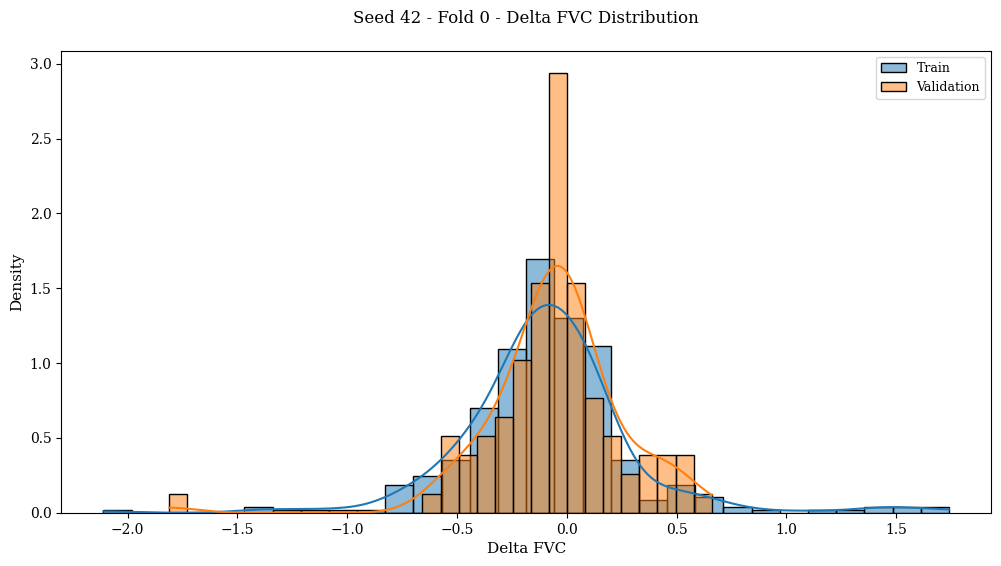

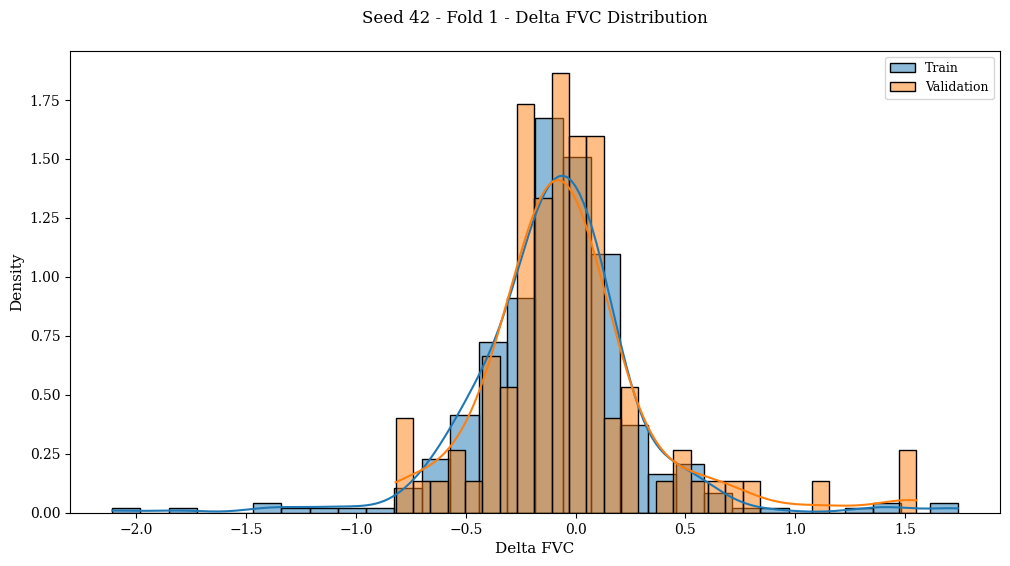

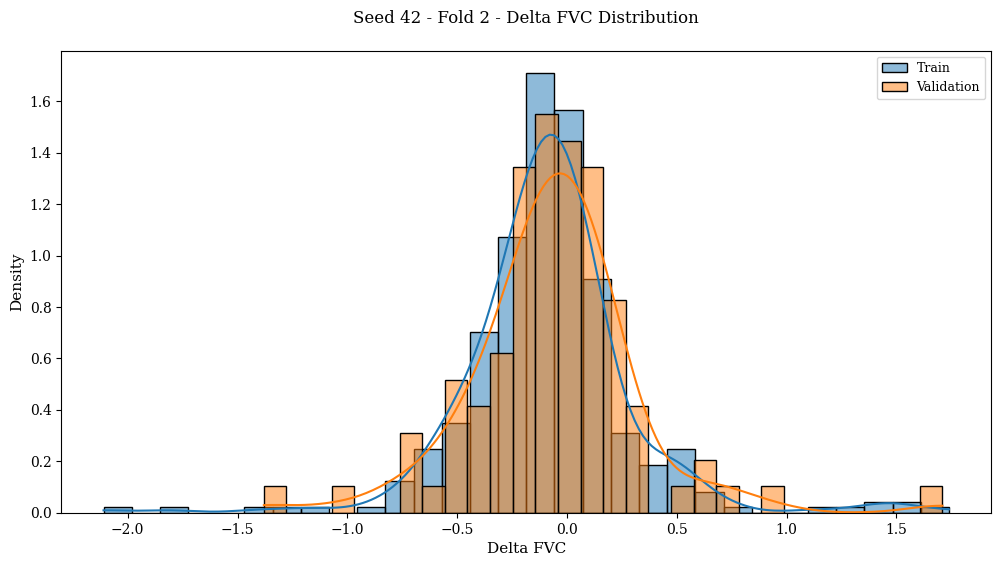

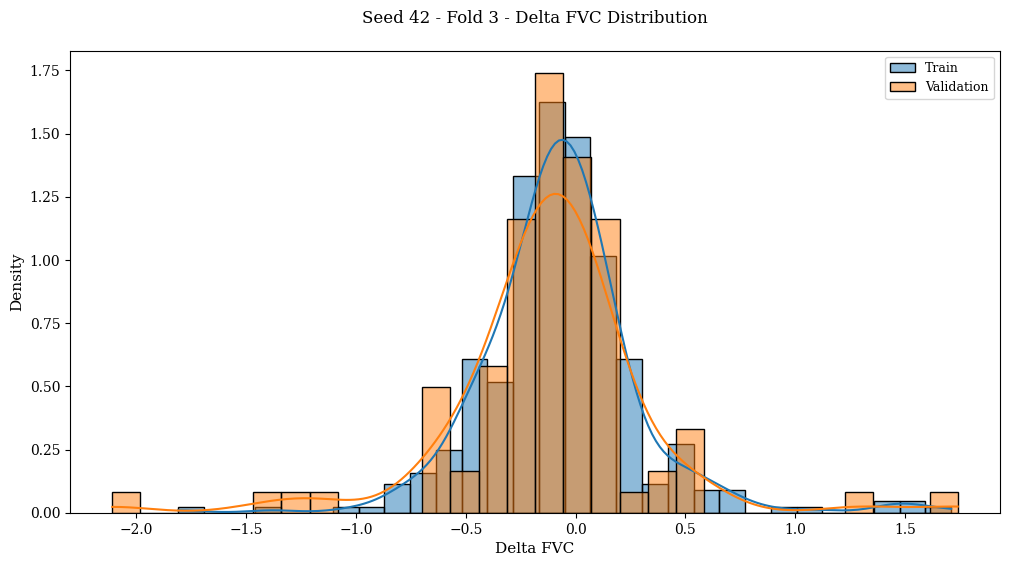

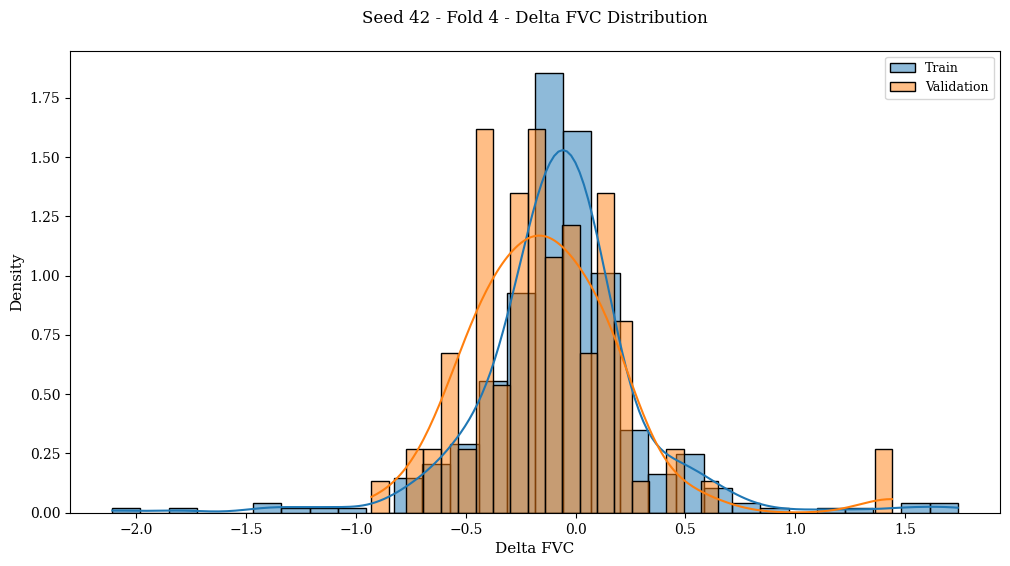

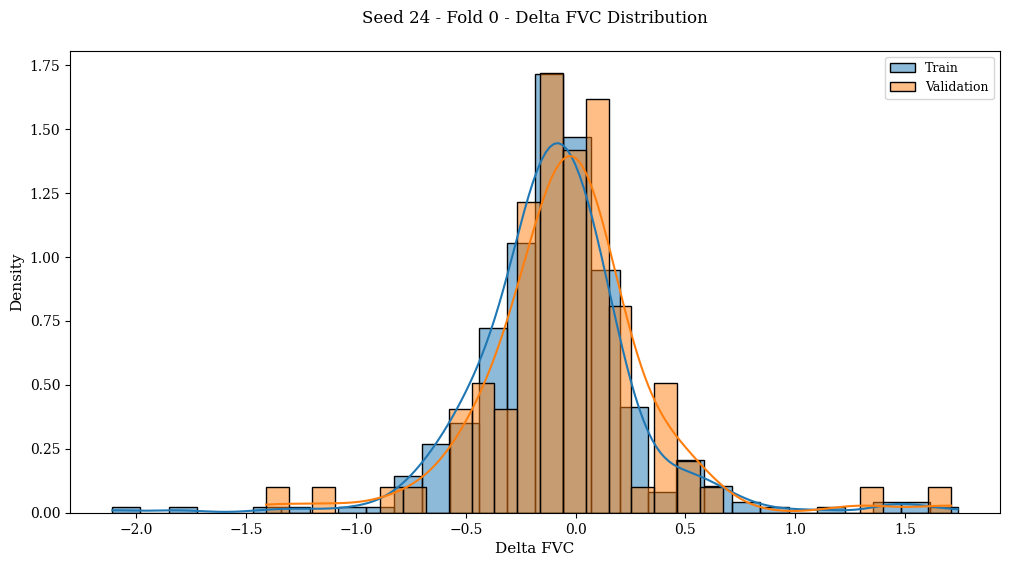

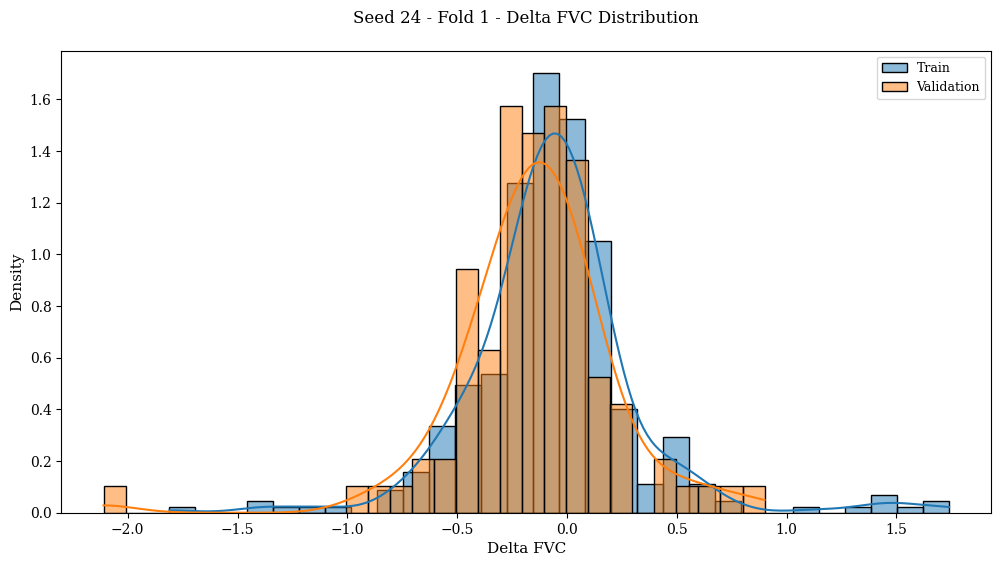

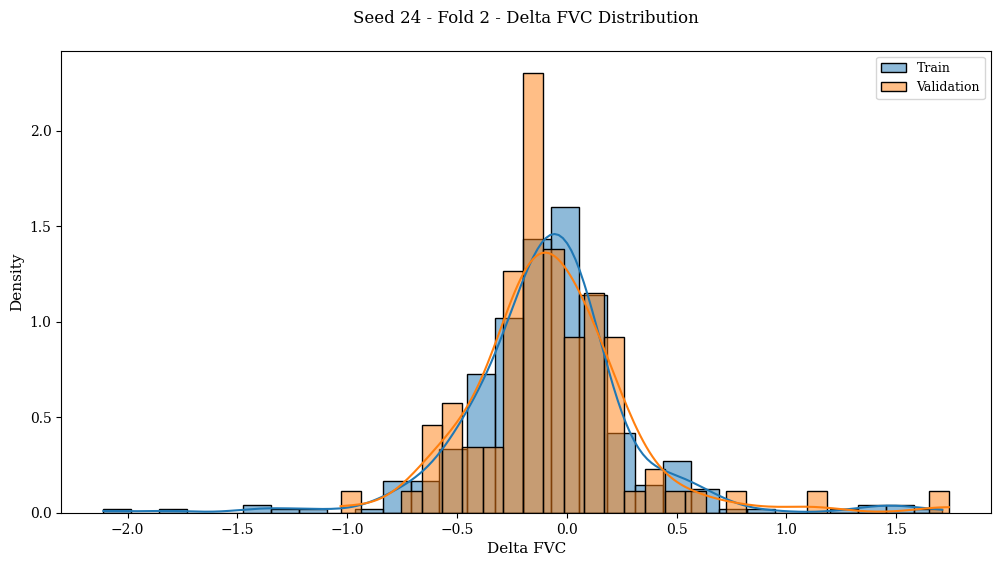

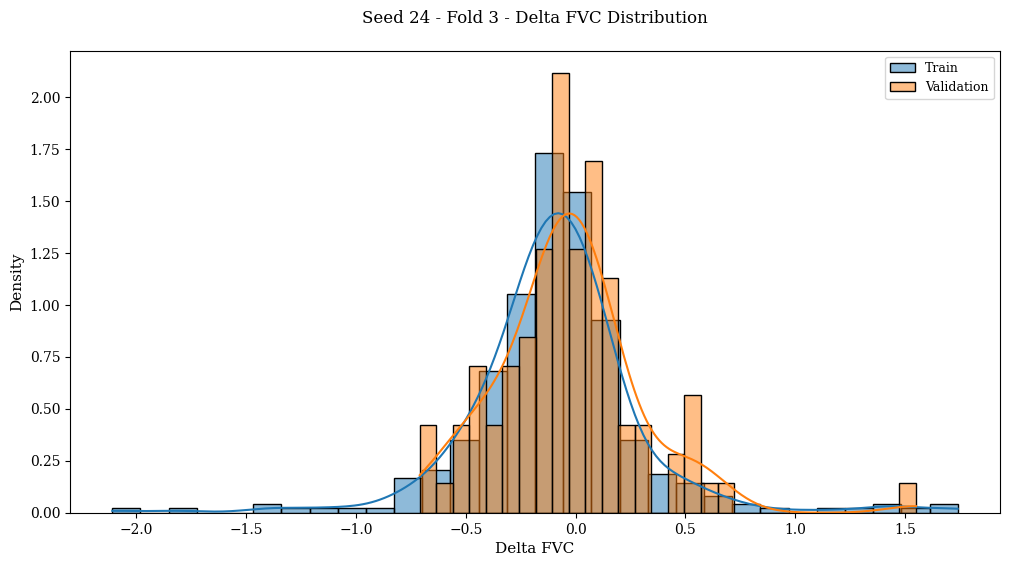

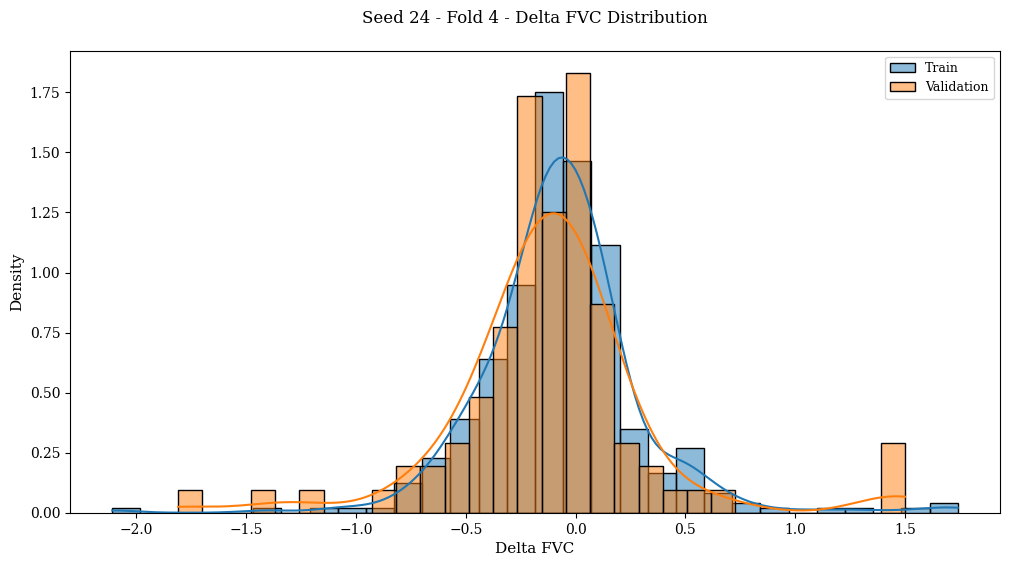

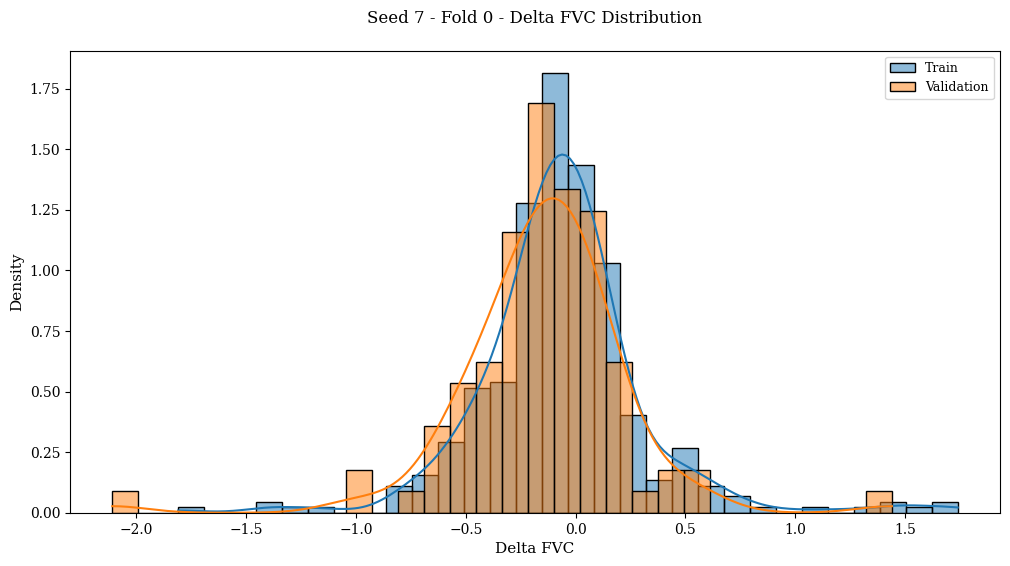

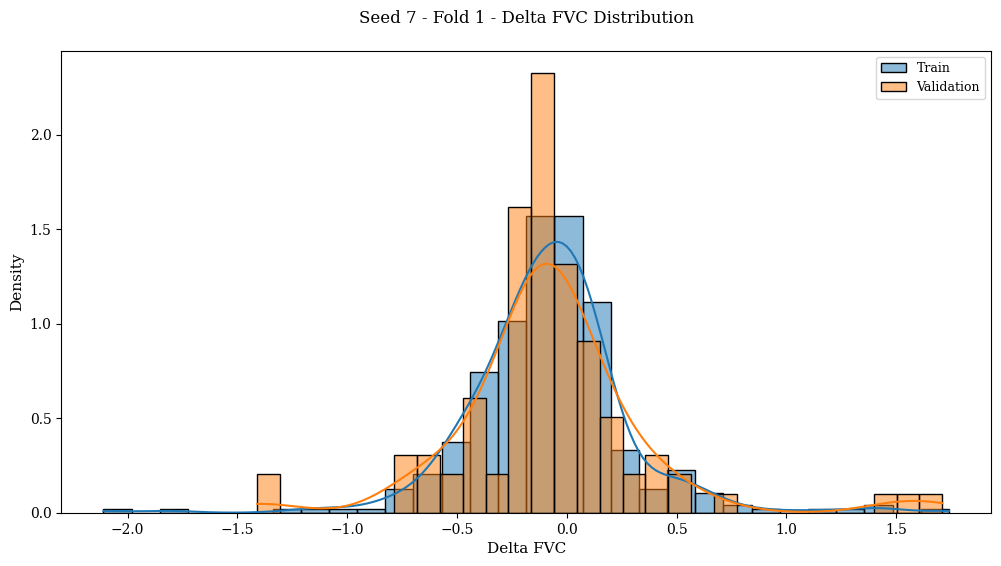

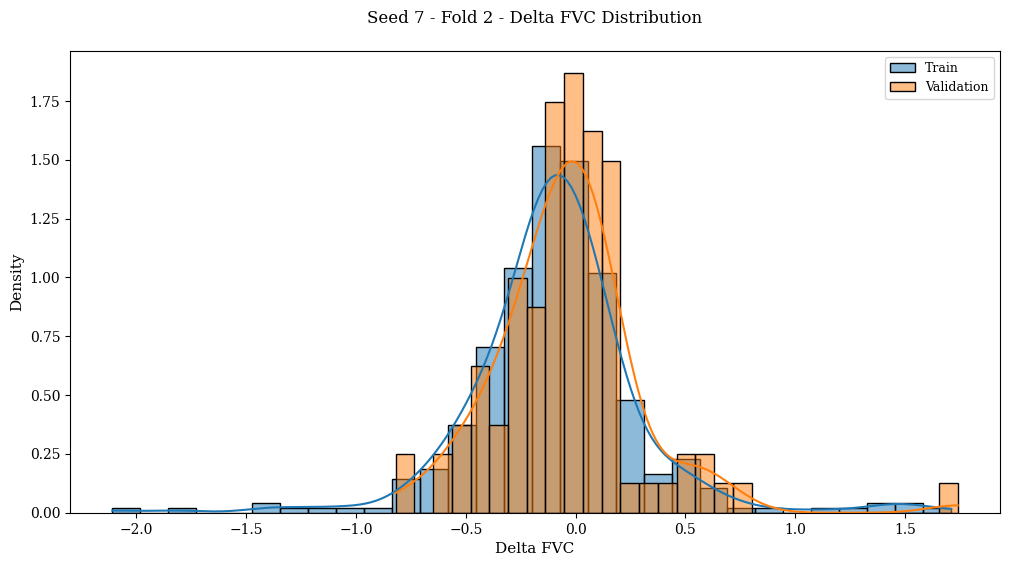

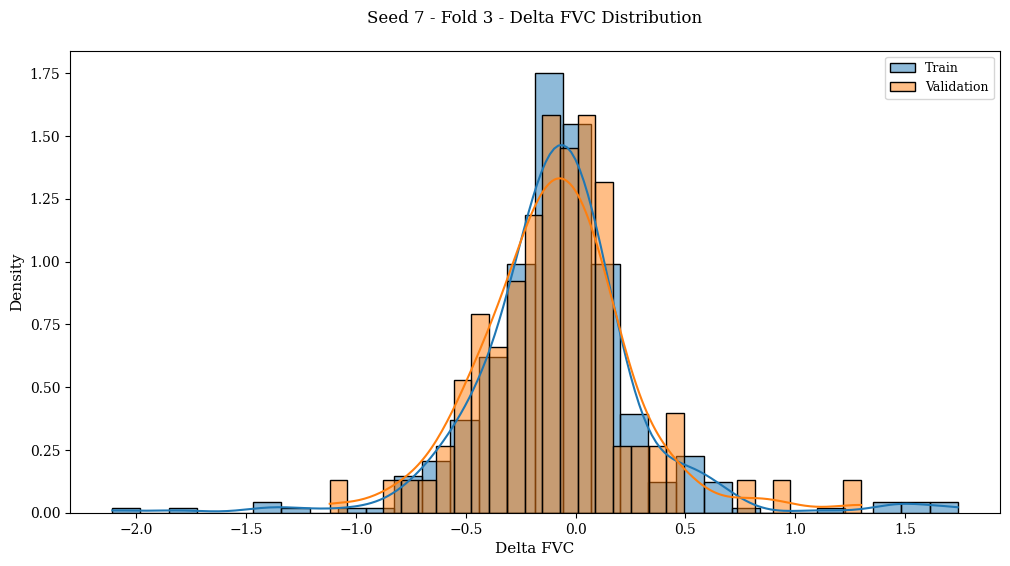

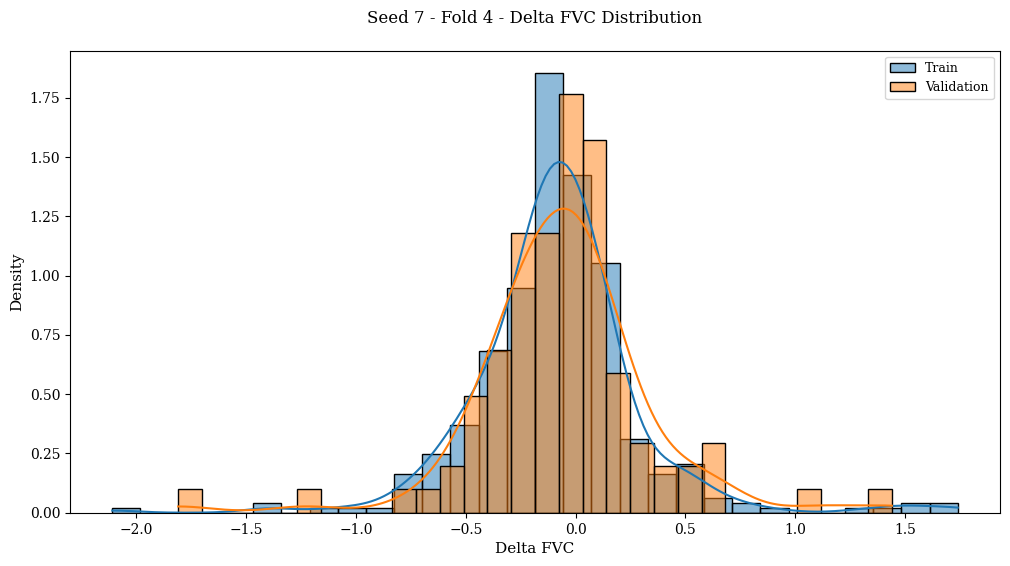

In [7]:
# Plot the distribution of delta FVC for each train/validation split
import seaborn as sns  
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 15,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlepad": 20,  # Add padding to titles

}) 

seeds = [42, 24, 7]

for seed in seeds:
    output_directory = f'Patient_Splits_Seed{seed}'
    for fold_idx in range(5):
        train_ids_df = pd.read_csv(f'{output_directory}/train_fold_{fold_idx}.csv')
        val_ids_df = pd.read_csv(f'{output_directory}/val_fold_{fold_idx}.csv')
        
        fold_train_df = cases_df[cases_df['PatientID'].isin(train_ids_df['PatientID'])].copy()
        fold_val_df = cases_df[cases_df['PatientID'].isin(val_ids_df['PatientID'])].copy()
        
        plt.figure(figsize=(12, 6))
        sns.histplot(fold_train_df['Delta FVC'],  label='Train', kde=True, stat='density', bins=30)
        sns.histplot(fold_val_df['Delta FVC'], label='Validation', kde=True, stat='density', bins=30)
        plt.title(f'Seed {seed} - Fold {fold_idx} - Delta FVC Distribution')
        plt.xlabel('Delta FVC')
        plt.ylabel('Density')
        plt.legend()
        plt.show()

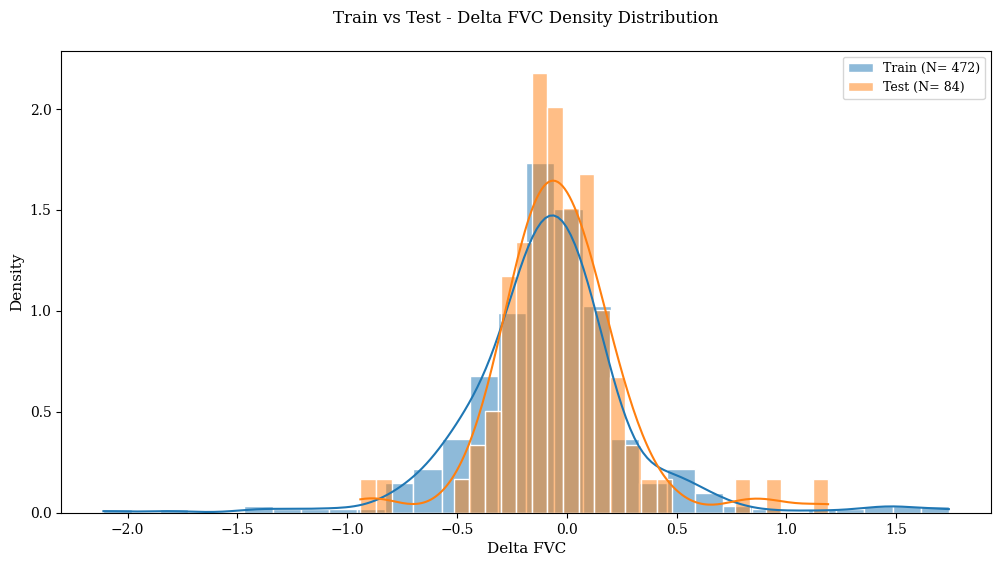

In [14]:
seed = 42
output_directory = f'Patient_Splits_Seed{seed}'
train_ids_df = pd.read_csv(f'{output_directory}/train_patients.csv')
test_ids_df = pd.read_csv(f'{output_directory}/test_patients.csv')
train_cases_df = cases_df[cases_df['PatientID'].isin(train_ids_df['PatientID'])].copy()
test_cases_df = cases_df[cases_df['PatientID'].isin(test_ids_df['PatientID'])].copy()
plt.figure(figsize=(12, 6))
sns.histplot(train_cases_df['Delta FVC'],  label=f'Train (N= {len(train_cases_df)})', kde=True, stat='density', bins=30, edgecolor='white')
sns.histplot(test_cases_df['Delta FVC'], label=f'Test (N= {len(test_cases_df)})', kde=True, stat='density', bins=30, edgecolor='white')
plt.title(f'Train vs Test - Delta FVC Density Distribution')
plt.xlabel('Delta FVC')
plt.ylabel('Density')
plt.legend()
plt.show()

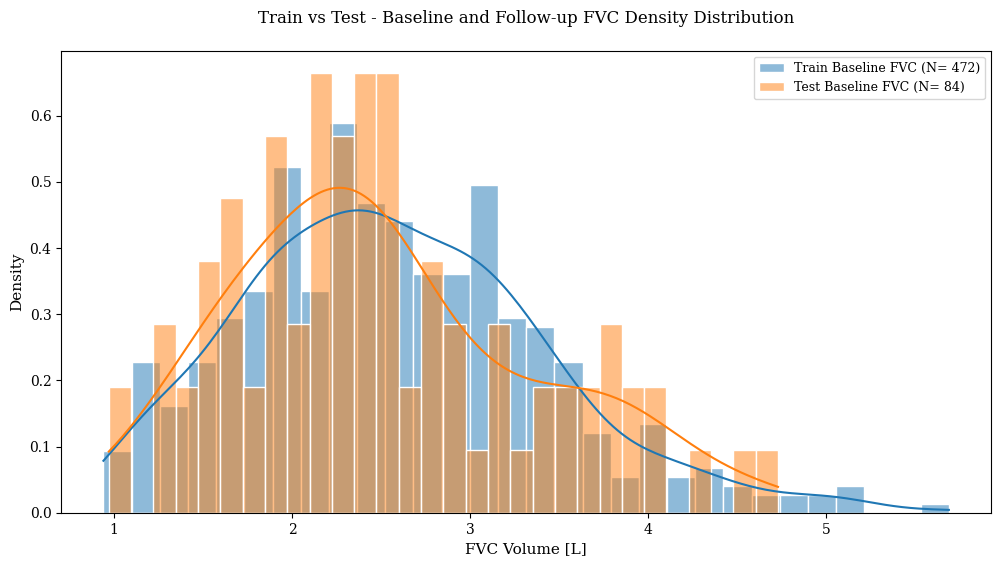

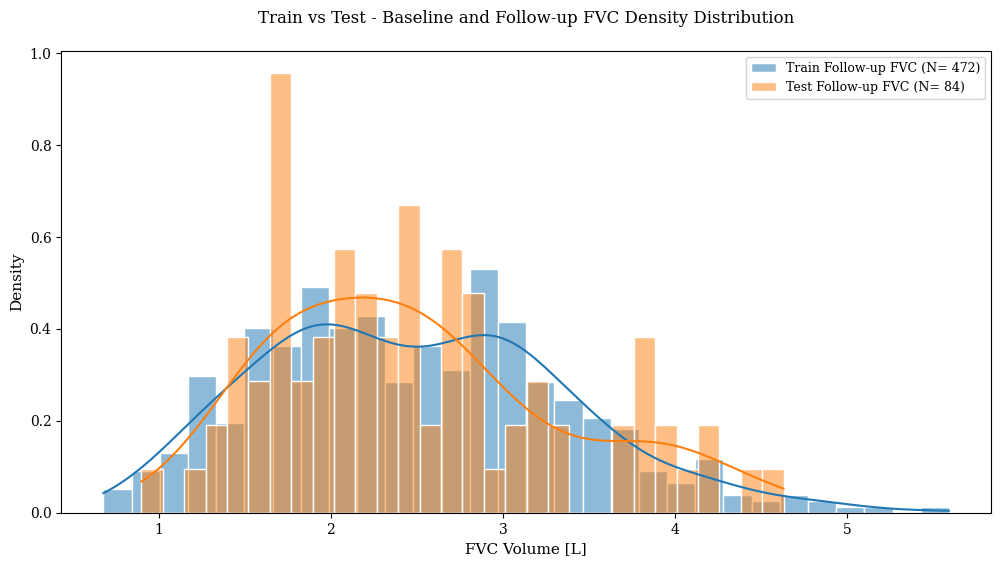

In [19]:
## plot the distribution of baseline and follow-up FVC volumes between train and test sets
plt.figure(figsize=(12, 6))
sns.histplot(train_cases_df['Baseline FVC Volume L'],  label=f'Train Baseline FVC (N= {len(train_cases_df)})', kde=True, stat='density', bins=30, edgecolor='white')
#sns.histplot(train_cases_df['Followup FVC Volume L'], label=f'Train Follow-up FVC (N= {len(train_cases_df)})', kde=True, stat='density', bins=30, edgecolor='white')
sns.histplot(test_cases_df['Baseline FVC Volume L'],  label=f'Test Baseline FVC (N= {len(test_cases_df)})', kde=True, stat='density', bins=30, edgecolor='white')
#sns.histplot(test_cases_df['Followup FVC Volume L'], label=f'Test Follow-up FVC (N= {len(test_cases_df)})', kde=True, stat='density', bins=30, edgecolor='white')   
plt.title(f'Train vs Test - Baseline and Follow-up FVC Density Distribution')
plt.xlabel('FVC Volume [L]')
plt.ylabel('Density')
plt.legend()
plt.show()

## plot the distribution of baseline and follow-up FVC volumes between train and test sets
plt.figure(figsize=(12, 6))
#sns.histplot(train_cases_df['Baseline FVC Volume L'],  label=f'Train Baseline FVC (N= {len(train_cases_df)})', kde=True, stat='density', bins=30, edgecolor='white')
sns.histplot(train_cases_df['Followup FVC Volume L'], label=f'Train Follow-up FVC (N= {len(train_cases_df)})', kde=True, stat='density', bins=30, edgecolor='white')
#sns.histplot(test_cases_df['Baseline FVC Volume L'],  label=f'Test Baseline FVC (N= {len(test_cases_df)})', kde=True, stat='density', bins=30, edgecolor='white')
sns.histplot(test_cases_df['Followup FVC Volume L'], label=f'Test Follow-up FVC (N= {len(test_cases_df)})', kde=True, stat='density', bins=30, edgecolor='white')   
plt.title(f'Train vs Test - Baseline and Follow-up FVC Density Distribution')
plt.xlabel('FVC Volume [L]')
plt.ylabel('Density')
plt.legend()
plt.show()